# Генератор пользовательских данных для подсчета клеток крови

## HT_6: Сегментация клеток крови с YOLO

**Задача:**
1. Преобразовать генератор данных — таргет: **сегментационные маски** (полигоны) + количество клеток
2. Для отделения сегментационных масок использовать **методы математической морфологии**
3. Натренировать **YOLOv8n-seg** для сегментации клеток
4. Определить количество клеток из сегментационных масок
5. Относительная погрешность подсчёта < 10%

**Доп. задание:**

Реализовать  при помощи библиотеки OpenCV алгоритм водораздела + distance transform для решения задачи сегментации пересекающихся клеток. 

Ссылка: OpenCV: [OpenCV: Image Segmentation with Watershed Algorithm](https://docs.opencv.org/4.x/d3/db4/tutorial_py_watershed.html)


In [ ]:
# Настройка окружения
import os
import cv2
import numpy as np
import random
import matplotlib.pyplot as plt
from typing import Tuple, List
from pathlib import Path
import yaml
from tqdm import tqdm
from torch.utils.data import Dataset

from ultralytics import YOLO

plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['axes.titlesize'] = 12
plt.rcParams['axes.labelsize'] = 10

In [3]:
# Фиксация сидов
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

In [4]:
def load_bccd_patches_to_ram(bccd_img_dir: str, bccd_mask_dir: str, patch_size=64):
    """Нарезка BCCD-датасета на патчи фона и клеток."""
    bg_patches, cell_patches = [], []

    if not os.path.exists(bccd_img_dir) or not os.path.exists(bccd_mask_dir):
        print("[WARN] Папки не найдены. Будет использована только синтетика.")
        return bg_patches, cell_patches

    print("Нарезка датасета...")
    mask_files = os.listdir(bccd_mask_dir)
    mask_dict = {os.path.splitext(f)[0]: f for f in mask_files}

    for img_name in os.listdir(bccd_img_dir):
        if not img_name.lower().endswith(('.jpg', '.jpeg', '.png')):
            continue
        img = cv2.imread(os.path.join(bccd_img_dir, img_name))
        if img is None:
            continue

        base_name = os.path.splitext(img_name)[0]
        if base_name not in mask_dict:
            continue

        mask = cv2.imread(os.path.join(bccd_mask_dir, mask_dict[base_name]), cv2.IMREAD_GRAYSCALE)
        if mask is None:
            continue

        _, mask_bin = cv2.threshold(mask, 10, 255, cv2.THRESH_BINARY)
        h, w = img.shape[:2]
        step = patch_size // 2

        for y in range(0, h - patch_size + 1, step):
            for x in range(0, w - patch_size + 1, step):
                p_mask = mask_bin[y:y+patch_size, x:x+patch_size]
                p_img = img[y:y+patch_size, x:x+patch_size]

                cell_pixels = np.sum(p_mask > 0)
                total_pixels = patch_size * patch_size

                if cell_pixels > total_pixels * 0.5:
                    cell_patches.append(p_img.copy())
                elif cell_pixels == 0:
                    bg_patches.append(p_img.copy())

    print(f"Загружено: {len(bg_patches)} фонов, {len(cell_patches)} клеток.")
    return bg_patches, cell_patches

In [ ]:
class BloodCellDataset(Dataset):
    """
    Генератор изображений клеток для YOLO-сегментации.

    Возвращает: (image_bgr, polygons, cell_mask, actual_count)
      - image_bgr:   numpy.ndarray (H, W, 3) BGR
      - polygons:    list of list[float] — нормализованные полигоны
                     [[x1,y1,x2,y2,...,xn,yn], ...]
      - cell_mask:   numpy.ndarray (H, W) — бинарная маска всех клеток
      - actual_count: количество размещённых клеток

    Генерация:
      - mask-based compositing (пиксель-в-пиксель)
      - cv2.findContours для получения полигонов каждой клетки
      - coverage check для предотвращения перекрытия
    """

    def __init__(
        self,
        img_size: Tuple[int, int] = (640, 640),
        dataset_size: int = 200,
        bg_patches: List[np.ndarray] = None,
        cell_patches: List[np.ndarray] = None,
        min_cells: int = 5,
        max_cells: int = 15,
        min_cell_radius: int = 12,
        max_cell_radius: int = 30,
        min_cell_coverage: float = 0.3,
        seed: int = 42
    ):
        super().__init__()
        random.seed(seed)
        np.random.seed(seed)

        self.img_size = img_size
        self.dataset_size = dataset_size
        self.bg_patches = bg_patches if bg_patches else []
        self.cell_patches = cell_patches if cell_patches else []
        self.min_cells = min_cells
        self.max_cells = max_cells
        self.min_cell_radius = min_cell_radius
        self.max_cell_radius = max_cell_radius
        self.min_cell_coverage = min_cell_coverage

    def __len__(self) -> int:
        return self.dataset_size

    def __getitem__(self, idx: int):
        h, w = self.img_size

        # Фон
        clean_img = self._select_background(h, w)

        # Размещение клеток 
        cells_count = random.randint(self.min_cells, self.max_cells)

        cells_img = np.zeros((h, w, 3), dtype=np.uint8)
        cells_mask = np.zeros((h, w), dtype=np.uint8)
        polygons = []        # YOLO сегментация: [[x1,y1,...,xn,yn], ...]
        actual_count = 0

        for _ in range(cells_count):
            placed = False
            for _attempt in range(2000):
                temp_img = np.zeros((h, w, 3), dtype=np.uint8)
                temp_mask = np.zeros((h, w), dtype=np.uint8)

                cx = random.randint(self.max_cell_radius + 5, w - self.max_cell_radius - 5)
                cy = random.randint(self.max_cell_radius + 5, h - self.max_cell_radius - 5)

                if len(self.cell_patches) > 0 and random.random() < 0.5:
                    # Реальный патч 
                    patch = random.choice(self.cell_patches)
                    new_size = random.randint(self.min_cell_radius * 2,
                                              self.max_cell_radius * 2)
                    patch = cv2.resize(patch, (new_size, new_size))
                    ph, pw = patch.shape[:2]

                    x1 = max(0, cx - pw // 2)
                    y1 = max(0, cy - ph // 2)
                    x2 = min(w, x1 + pw)
                    y2 = min(h, y1 + ph)

                    patch_gray = cv2.cvtColor(patch, cv2.COLOR_BGR2GRAY)
                    _, patch_mask = cv2.threshold(patch_gray, 5, 255, cv2.THRESH_BINARY)

                    temp_mask[y1:y2, x1:x2] = patch_mask[:y2-y1, :x2-x1]
                    temp_img[y1:y2, x1:x2] = patch[:y2-y1, :x2-x1]
                else:
                    # Синтетическая клетка (круг)
                    rad = random.randint(self.min_cell_radius, self.max_cell_radius)
                    color = self._get_cell_color()

                    cv2.circle(temp_mask, (cx, cy), rad, 255, -1)
                    cv2.circle(temp_img, (cx, cy), rad, color, -1)
                    # Мембрана
                    stroke = (min(255, color[0] + 60),
                              min(255, color[1] + 60),
                              min(255, color[2] + 60))
                    cv2.circle(temp_img, (cx, cy), rad, stroke, 2)

                # Coverage check
                overlap = cv2.bitwise_and(temp_mask, cells_mask)
                new_only = cv2.bitwise_and(temp_mask, cv2.bitwise_not(cells_mask))

                total_px = np.count_nonzero(temp_mask)
                if total_px == 0:
                    continue

                coverage = np.count_nonzero(new_only) / total_px

                if coverage >= self.min_cell_coverage:
                    # Размещаем
                    cells_img = self._add_image_with_mask(cells_img, temp_img, new_only)
                    cells_mask = cv2.bitwise_or(cells_mask, temp_mask)

                    # Извлекаем полигон из маски этой клетки
                    contours, _ = cv2.findContours(
                        new_only, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE
                    )
                    if contours:
                        # Берём самый большой контур
                        cnt = max(contours, key=cv2.contourArea)
                        if len(cnt) >= 3:
                            pts = cnt.reshape(-1, 2).astype(np.float32)
                            # Нормализация [0, 1]
                            pts[:, 0] /= w
                            pts[:, 1] /= h
                            polygon = pts.flatten().tolist()
                            polygons.append(polygon)

                    actual_count += 1
                    placed = True
                    break

        # Наложение на фон
        clean_img = self._add_image_with_mask(clean_img, cells_img, cells_mask)

        return clean_img, polygons, cells_mask, actual_count

    def _select_background(self, h: int, w: int) -> np.ndarray:
        """Тайловый фон или однотонный."""
        if len(self.bg_patches) > 0 and random.random() > 0.3:
            bg = np.zeros((h, w, 3), dtype=np.uint8)
            tile = 128
            for iy in range(0, h, tile):
                for ix in range(0, w, tile):
                    p = random.choice(self.bg_patches)
                    p = cv2.resize(p, (tile, tile))
                    he = min(iy + tile, h)
                    we = min(ix + tile, w)
                    bg[iy:he, ix:we] = p[:he-iy, :we-ix]
            bg = cv2.GaussianBlur(bg, (3, 3), 0)
        else:
            c = [random.randint(180, 240), random.randint(180, 240), random.randint(180, 240)]
            bg = np.full((h, w, 3), c, dtype=np.uint8)
        return bg

    def _get_cell_color(self) -> Tuple[int, int, int]:
        return (random.randint(100, 220), random.randint(80, 200), random.randint(80, 200))

    @staticmethod
    def _add_image_with_mask(dst, src, mask):
        result = dst.copy()
        result[mask > 0] = src[mask > 0]
        return result

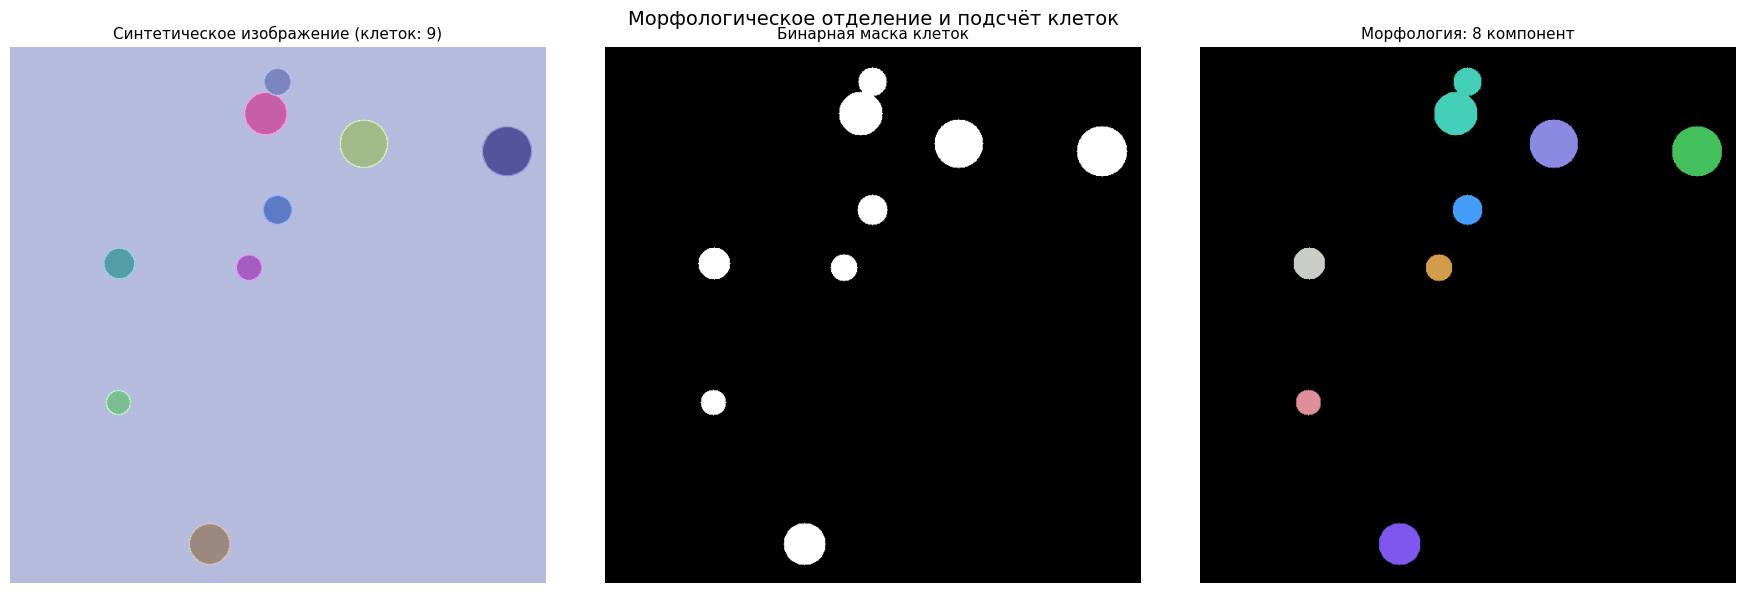

Ground truth: 9 клеток
Морфология:   8 компонент
Совпадение:   ✗


In [ ]:
# Демонстрация: морфологический подсчёт клеток
def count_cells_by_morphology(
    binary_mask: np.ndarray,
    kernel_size: int = 5,
    min_area: int = 50
) -> Tuple[int, np.ndarray]:
    """
    Подсчёт клеток на бинарной маске с помощью морфологии.

    Шаги:
      1. Морфологическое открытие (erosion + dilation) — разделение слияний
      2. cv2.connectedComponentsWithStats — поиск компонент
      3. Фильтрация по минимальной площади (удаление шума)

    Возвращает: (count, labeled_mask)
    """
    # Морфологическое открытие: erosion → dilation
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (kernel_size, kernel_size))
    opened = cv2.morphologyEx(binary_mask, cv2.MORPH_OPEN, kernel, iterations=2)

    # Связные компоненты
    num_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(opened, connectivity=8)

    # Фильтрация: минимальная площадь (отсеиваем шум)
    count = 0
    for i in range(1, num_labels):  # 0 = фон
        area = stats[i, cv2.CC_STAT_AREA]
        if area >= min_area:
            count += 1

    return count, labels


# Демонстрация на примере
random.seed(SEED)
demo_dataset = BloodCellDataset(
    img_size=(640, 640), dataset_size=1,
    bg_patches=[], cell_patches=[],
    min_cells=5, max_cells=15,
    min_cell_radius=12, max_cell_radius=30,
    seed=SEED
)
demo_img, demo_polygons, demo_mask, demo_count = demo_dataset[0]

morph_count, labeled = count_cells_by_morphology(demo_mask, kernel_size=5, min_area=50)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Исходное изображение
axes[0].imshow(cv2.cvtColor(demo_img, cv2.COLOR_BGR2RGB))
axes[0].set_title(f"Синтетическое изображение (клеток: {demo_count})", fontsize=11)
axes[0].axis('off')

# Бинарная маска
axes[1].imshow(demo_mask, cmap='gray')
axes[1].set_title(f"Бинарная маска клеток", fontsize=11)
axes[1].axis('off')

# Морфология + компоненты (цветная разметка)
colors_mask = np.zeros((640, 640, 3), dtype=np.uint8)
num_l = labeled.max()
if num_l > 0:
    rng = np.random.default_rng(42)
    for lbl in range(1, num_l + 1):
        color = rng.integers(50, 255, size=3).tolist()
        colors_mask[labeled == lbl] = color
axes[2].imshow(colors_mask)
axes[2].set_title(f"Морфология: {morph_count} компонент", fontsize=11)
axes[2].axis('off')

plt.suptitle("Морфологическое отделение и подсчёт клеток", fontsize=14)
plt.tight_layout()
plt.show()

print(f"Ground truth: {demo_count} клеток")
print(f"Морфология:   {morph_count} компонент")
print(f"Совпадение:   {'✓' if morph_count == demo_count else '✗'}")

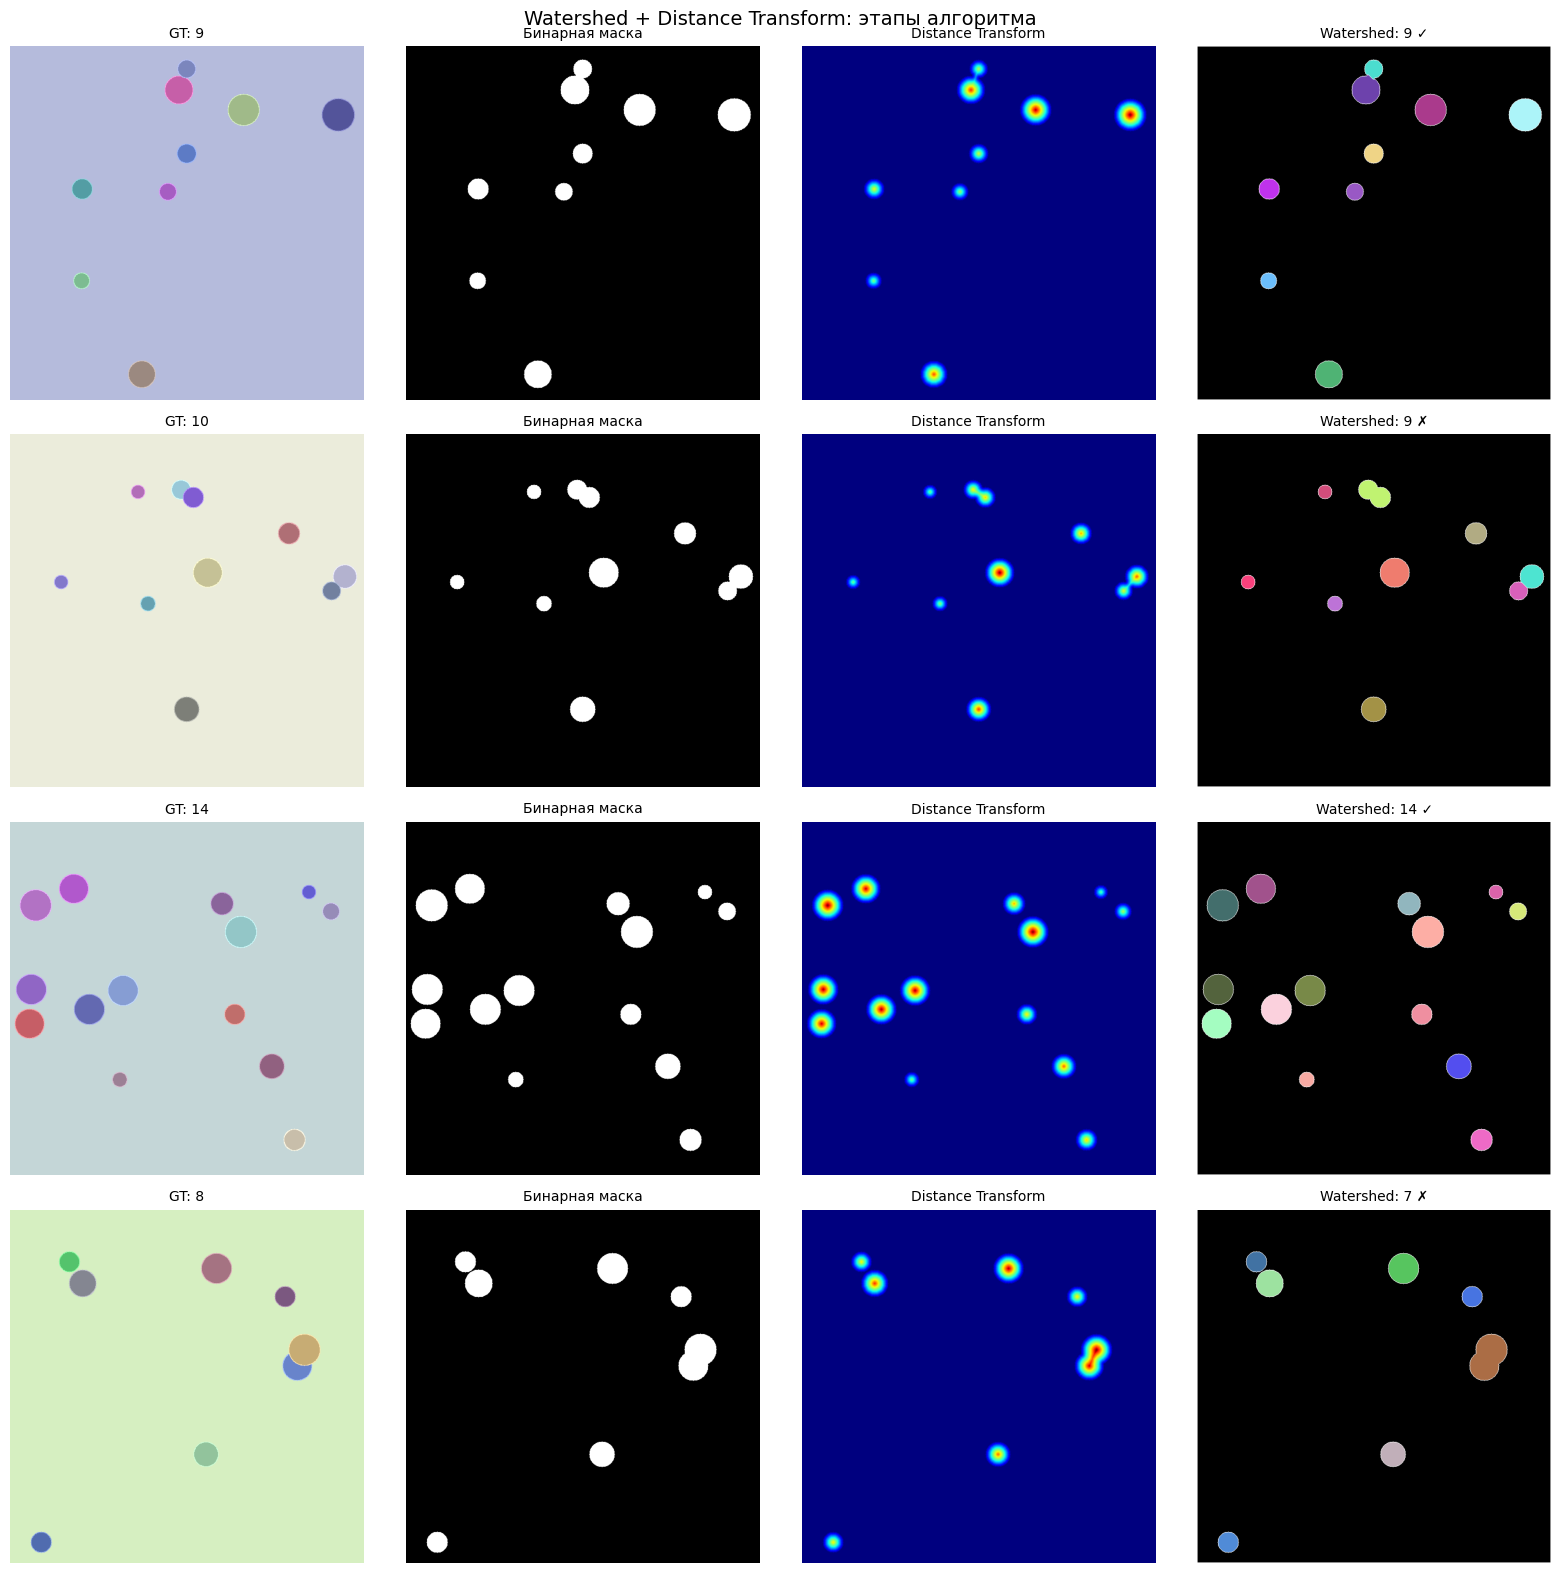

In [ ]:
# Алгоритм водораздела (Watershed + Distance Transform)
def count_cells_by_watershed(
    binary_mask: np.ndarray,
    dist_thresh_ratio: float = 0.5,
    min_area: int = 50
) -> Tuple[int, np.ndarray]:
    """
    Подсчёт клеток на бинарной маске с помощью Watershed.

    Параметры:
      dist_thresh_ratio — порог distance transform (доля от максимума).
        Чем выше → меньше sure_fg → меньше маркеров → агрессивнее разделение.
      min_area — минимальная площадь компоненты (фильтр шума).

    Возвращает: (count, labeled_mask)
    """
    if binary_mask.max() == 0:
        return 0, np.zeros_like(binary_mask, dtype=np.int32)

    # Удаление шума: морфологическое открытие
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (3, 3))
    opened = cv2.morphologyEx(binary_mask, cv2.MORPH_OPEN, kernel, iterations=2)

    # Sure background — дилатация 
    sure_bg = cv2.dilate(opened, kernel, iterations=3)

    # Расстояние от каждого пикселя до ближайшего нулевого (фонового) пикселя
    dist_transform = cv2.distanceTransform(opened, cv2.DIST_L2, 5)

    # Sure foreground: пиксели, расстояние которых > порога 
    ret, sure_fg = cv2.threshold(
        dist_transform,
        dist_thresh_ratio * dist_transform.max(),
        255, cv2.THRESH_BINARY
    )
    sure_fg = sure_fg.astype(np.uint8)

    # То, что точно не фон и не точно клетка
    unknown = cv2.subtract(sure_bg, sure_fg)

    # Маркеры: connected components на sure_fg
    # Каждый отдельный кластер sure_fg = отдельная клетка
    ret_markers, markers = cv2.connectedComponents(sure_fg)

    # Прибавляем 1 ко всем маркерам, чтобы фон = 1 (не 0)
    markers = markers + 1

    # Помечаем unknown region как 0
    markers[unknown > 0] = 0

    # Watershed
    img_3ch = cv2.cvtColor(binary_mask, cv2.COLOR_GRAY2BGR)
    markers = cv2.watershed(img_3ch, markers)

    # Подсчёт: число уникальных маркеров, исключая:-1 (границы, которые watershed пометил), 1 (фон)
    unique_labels = np.unique(markers)
    count = 0
    for lbl in unique_labels:
        if lbl <= 1: 
            continue
        area = np.sum(markers == lbl)
        if area >= min_area:
            count += 1

    return count, markers


# Демонстрация на нескольких примерах
random.seed(SEED)
demo_ws = BloodCellDataset(
    img_size=(640, 640), dataset_size=4,
    bg_patches=[], cell_patches=[],
    min_cells=5, max_cells=15,
    min_cell_radius=12, max_cell_radius=30,
    seed=SEED
)

fig, axes = plt.subplots(4, 4, figsize=(16, 16))
fig.suptitle("Watershed + Distance Transform: этапы алгоритма", fontsize=14)

for i in range(4):
    img, polys, mask, gt_count = demo_ws[i]
    h, w = img.shape[:2]

    # Watershed
    ws_count, ws_markers = count_cells_by_watershed(mask, dist_thresh_ratio=0.4, min_area=50)

    # Distance transform для визуализации
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (3, 3))
    opened = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel, iterations=2)
    dist = cv2.distanceTransform(opened, cv2.DIST_L2, 5)

    # Col 0: изображение
    axes[i, 0].imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    axes[i, 0].set_title(f"GT: {gt_count}", fontsize=10)
    axes[i, 0].axis('off')

    # Col 1: бинарная маска
    axes[i, 1].imshow(mask, cmap='gray')
    axes[i, 1].set_title("Бинарная маска", fontsize=10)
    axes[i, 1].axis('off')

    # Col 2: distance transform
    axes[i, 2].imshow(dist, cmap='jet')
    axes[i, 2].set_title("Distance Transform", fontsize=10)
    axes[i, 2].axis('off')

    # Col 3: watershed результат (цветная разметка)
    ws_colored = np.zeros((h, w, 3), dtype=np.uint8)
    unique_labels = np.unique(ws_markers)
    rng = np.random.default_rng(i + 100)
    for lbl in unique_labels:
        if lbl <= 1:
            continue
        color = rng.integers(50, 255, size=3).tolist()
        ws_colored[ws_markers == lbl] = color
    # Рисуем границы (-1)
    ws_colored[ws_markers == -1] = (255, 255, 255)
    axes[i, 3].imshow(cv2.cvtColor(ws_colored, cv2.COLOR_BGR2RGB))
    match = '✓' if ws_count == gt_count else '✗'
    axes[i, 3].set_title(f"Watershed: {ws_count} {match}", fontsize=10)
    axes[i, 3].axis('off')

plt.tight_layout()
plt.show()

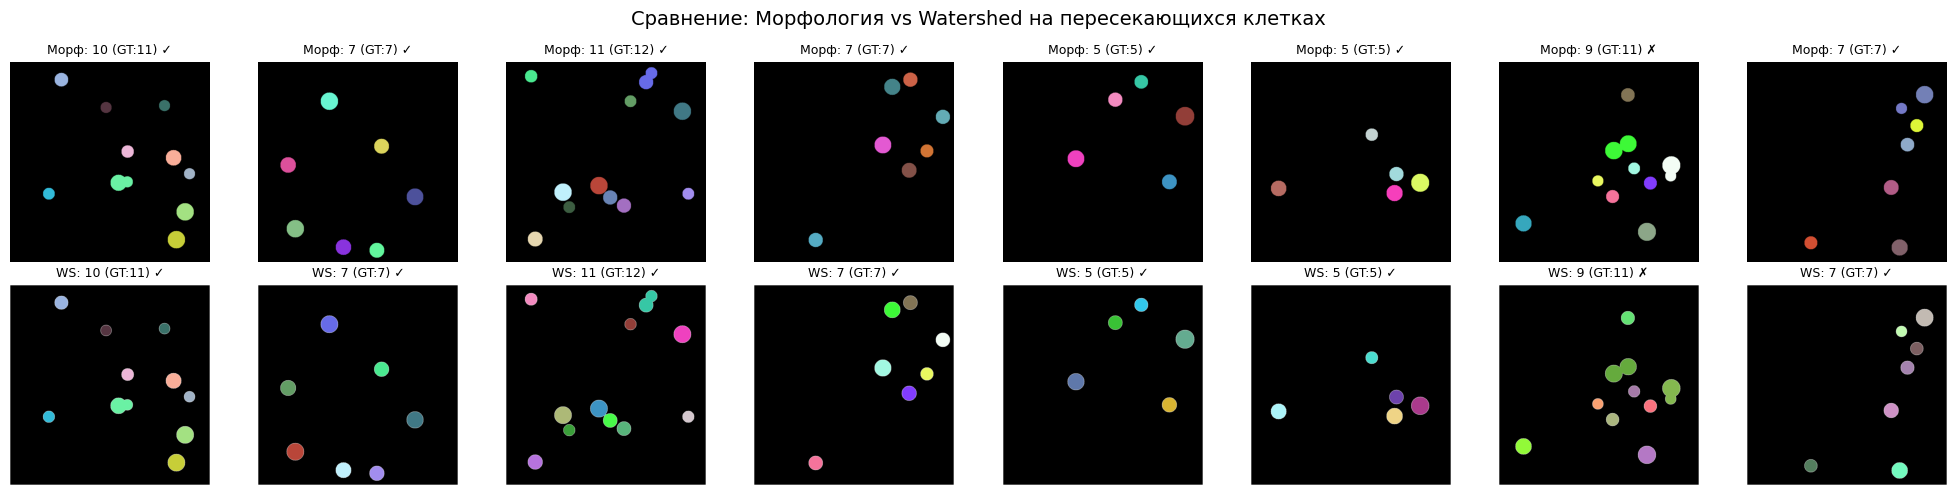

Морфология: 7/8 корректных
Watershed:   7/8 корректных
Вывод: результаты сопоставимы (точная настройка в ячейке 26)


In [ ]:
# Сравнение: Морфология vs Watershed

random.seed(123)
compare_ds = BloodCellDataset(
    img_size=(640, 640), dataset_size=8,
    bg_patches=[], cell_patches=[],
    min_cells=5, max_cells=12,
    min_cell_radius=18, max_cell_radius=30,
    min_cell_coverage=0.25,   # 25% — умеренное пересечение клеток
    seed=123
)

fig, axes = plt.subplots(2, 8, figsize=(20, 5))
fig.suptitle('Сравнение: Морфология vs Watershed на пересекающихся клетках', fontsize=14)

morph_ok = 0
ws_ok = 0

for i in range(8):
    img, polys, mask, gt_count = compare_ds[i]
    h, w = img.shape[:2]

    # Морфология: эрозия + дилатация + связные компоненты
    m_count, m_labels = count_cells_by_morphology(mask, kernel_size=5, min_area=100)
    m_flag = abs(m_count - gt_count) / max(gt_count, 1) < 0.15  # порог 15%
    if m_flag: morph_ok += 1

    # Watershed: distance transform + маркеры + водораздел
    w_count, w_markers = count_cells_by_watershed(mask, dist_thresh_ratio=0.3, min_area=100)
    w_flag = abs(w_count - gt_count) / max(gt_count, 1) < 0.15  # порог 15%
    if w_flag: ws_ok += 1

    # Верхний ряд: морфология
    m_colored = np.zeros((h, w, 3), dtype=np.uint8)
    num_m = m_labels.max()
    if num_m > 0:
        rng_m = np.random.default_rng(i * 10)
        for lbl in range(1, num_m + 1):
            color = rng_m.integers(50, 255, size=3).tolist()
            m_colored[m_labels == lbl] = color
    axes[0, i].imshow(cv2.cvtColor(m_colored, cv2.COLOR_BGR2RGB))
    m_mark = chr(10003) if m_flag else chr(10007)  # ✓ / ✗
    axes[0, i].set_title(f'Mорф: {m_count} (GT:{gt_count}) {m_mark}', fontsize=9)
    axes[0, i].axis('off')

    # Нижний ряд: watershed
    w_colored = np.zeros((h, w, 3), dtype=np.uint8)
    unique_lbl = np.unique(w_markers)
    rng_w = np.random.default_rng(i * 20)
    for lbl in unique_lbl:
        if lbl <= 1: continue
        color = rng_w.integers(50, 255, size=3).tolist()
        w_colored[w_markers == lbl] = color
    w_colored[w_markers == -1] = (255, 255, 255)
    axes[1, i].imshow(cv2.cvtColor(w_colored, cv2.COLOR_BGR2RGB))
    w_mark = chr(10003) if w_flag else chr(10007)  # ✓ / ✗
    axes[1, i].set_title(f'WS: {w_count} (GT:{gt_count}) {w_mark}', fontsize=9)
    axes[1, i].axis('off')

plt.tight_layout()
plt.show()

print(f'Морфология: {morph_ok}/8 корректных')
print(f'Watershed:   {ws_ok}/8 корректных')
if ws_ok > morph_ok:
    print('Вывод: Watershed лучше разделяет пересекающиеся клетки')
else:
    print('Вывод: результаты сопоставимы (точная настройка в ячейке 26)')


In [9]:
# Загрузка патчей BCCD
bccd_img_dir = "bccd/train/images"
bccd_mask_dir = "bccd/train/masks"
bg_patches_list = []
cell_patches_list = []

if os.path.exists(bccd_img_dir) and os.path.exists(bccd_mask_dir):
    bg_patches_list, cell_patches_list = load_bccd_patches_to_ram(
        bccd_img_dir=bccd_img_dir,
        bccd_mask_dir=bccd_mask_dir,
        patch_size=64
    )
else:
    print("[INFO] BCCD не найден. Используем синтетику.")

print(f"Фонов: {len(bg_patches_list)}, Клеток: {len(cell_patches_list)}")

Нарезка датасета...
Загружено: 794246 фонов, 621732 клеток.
Фонов: 794246, Клеток: 621732


In [ ]:
# Параметры
IMG_SIZE = (640, 640)
TRAIN_SIZE = 500
VAL_SIZE   = 100
TEST_SIZE  = 50
MIN_CELLS  = 5
MAX_CELLS  = 15
MIN_CELL_RADIUS = 12
MAX_CELL_RADIUS = 30

SEG_DATASET_DIR = "yolo_seg_dataset"

print(f"Генерация {TRAIN_SIZE} train + {VAL_SIZE} val ({IMG_SIZE})...")
print(f"Клетки: {MIN_CELLS}–{MAX_CELLS}, радиус: {MIN_CELL_RADIUS}–{MAX_CELL_RADIUS} px")

Генерация 500 train + 100 val ((640, 640))...
Клетки: 5–15, радиус: 12–30 px


In [11]:
import shutil

if os.path.exists(SEG_DATASET_DIR):
    shutil.rmtree(SEG_DATASET_DIR)

for split in ['train', 'val']:
    os.makedirs(f"{SEG_DATASET_DIR}/images/{split}", exist_ok=True)
    os.makedirs(f"{SEG_DATASET_DIR}/labels/{split}", exist_ok=True)

CLASS_ID = 0


def generate_seg_dataset(split: str, num_images: int, seed: int):
    """Генерация изображений и YOLO-сегментационных аннотаций."""
    dataset = BloodCellDataset(
        img_size=IMG_SIZE, dataset_size=num_images,
        bg_patches=bg_patches_list, cell_patches=cell_patches_list,
        min_cells=MIN_CELLS, max_cells=MAX_CELLS,
        min_cell_radius=MIN_CELL_RADIUS, max_cell_radius=MAX_CELL_RADIUS,
        seed=seed
    )

    total_cells = 0
    total_polygons = 0
    no_poly = 0

    for i in tqdm(range(len(dataset)), desc=f"Генерация {split}"):
        clean_img, polygons, cell_mask, num_cells = dataset[i]

        img_fname = f"{split}_{i:05d}.jpg"
        lbl_fname = f"{split}_{i:05d}.txt"

        cv2.imwrite(f"{SEG_DATASET_DIR}/images/{split}/{img_fname}", clean_img)

        # YOLO segmentation format: class_id x1 y1 x2 y2 ... xn yn
        with open(f"{SEG_DATASET_DIR}/labels/{split}/{lbl_fname}", 'w') as f:
            for poly in polygons:
                coords = ' '.join(f"{v:.6f}" for v in poly)
                f.write(f"{CLASS_ID} {coords}\n")

        total_cells += num_cells
        total_polygons += len(polygons)
        if len(polygons) == 0 and num_cells > 0:
            no_poly += 1

    print(f"  {split}: {num_images} изобр., "
          f"{total_cells} клеток, {total_polygons} полигонов, "
          f"{no_poly} без полигонов")


generate_seg_dataset('train', TRAIN_SIZE, seed=SEED)
generate_seg_dataset('val', VAL_SIZE, seed=SEED + 1)

Генерация train: 100%|██████████| 500/500 [00:13<00:00, 36.32it/s]


  train: 500 изобр., 4945 клеток, 4945 полигонов, 0 без полигонов


Генерация val: 100%|██████████| 100/100 [00:02<00:00, 38.53it/s]

  val: 100 изобр., 937 клеток, 937 полигонов, 0 без полигонов


In [12]:
# data.yaml
data_yaml = {
    'path': os.path.abspath(SEG_DATASET_DIR),
    'train': 'images/train',
    'val': 'images/val',
    'names': {0: 'blood_cell'},
    'nc': 1
}

yaml_path = f"{SEG_DATASET_DIR}/data.yaml"
with open(yaml_path, 'w') as f:
    yaml.dump(data_yaml, f, default_flow_style=False)

print(f"data.yaml: {yaml_path}")
print(yaml.dump(data_yaml, default_flow_style=False))

data.yaml: yolo_seg_dataset/data.yaml
names:
  0: blood_cell
nc: 1
path: "c:\\Users\\Daniil\\Desktop\\Recent Study\\2 \u0441\u0435\u043C\u0435\u0441\u0442\
  \u0440\\\u0414\u0432\u0443\u043C\u0435\u0440\u043D\u0430\u044F \u0433\u0440\u0430\
  \u0444\u0438\u043A\u0430 \u0438 \u043E\u0431\u0440\u0430\u0431\u043E\u0442\u043A\
  \u0430 \u0432\u0438\u0434\u0435\u043E\\Practice_6\\yolo_seg_dataset"
train: images/train
val: images/val



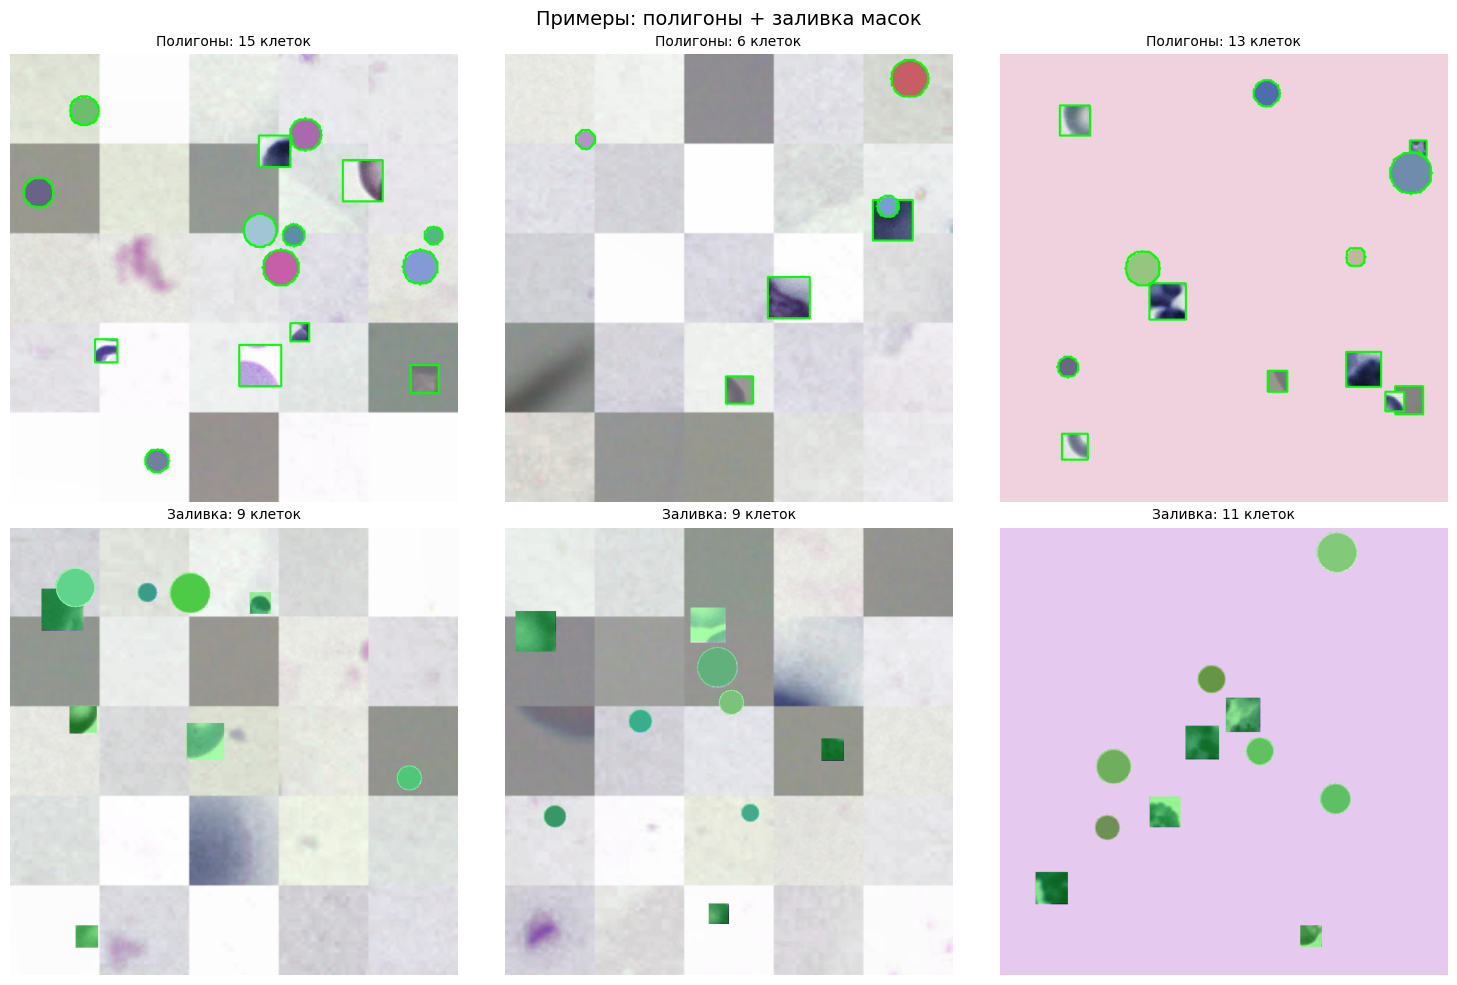

In [13]:
# Визуализация с сегментационными масками
def draw_polygons(img_bgr, polygons, color=(0, 255, 0), thickness=2):
    """Отрисовка YOLO полигонов на BGR-изображении."""
    img = img_bgr.copy()
    h, w = img.shape[:2]
    for poly in polygons:
        pts = np.array(poly).reshape(-1, 2)
        pts[:, 0] *= w
        pts[:, 1] *= h
        pts_int = pts.astype(np.int32)
        cv2.polylines(img, [pts_int], True, color, thickness)
    return img


def draw_filled_masks(img_bgr, polygons, alpha=0.35):
    """Заливка полигонов полупрозрачным цветом."""
    img = img_bgr.copy()
    h, w = img.shape[:2]
    overlay = img.copy()
    for poly in polygons:
        pts = np.array(poly).reshape(-1, 2)
        pts[:, 0] *= w
        pts[:, 1] *= h
        pts_int = pts.astype(np.int32)
        cv2.fillPoly(overlay, [pts_int], (0, 255, 0))
    return cv2.addWeighted(overlay, alpha, img, 1 - alpha, 0)


random.seed(SEED)
ds_viz = BloodCellDataset(
    img_size=IMG_SIZE, dataset_size=6,
    bg_patches=bg_patches_list, cell_patches=cell_patches_list,
    min_cells=MIN_CELLS, max_cells=MAX_CELLS,
    min_cell_radius=MIN_CELL_RADIUS, max_cell_radius=MAX_CELL_RADIUS,
    seed=SEED
)

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
fig.suptitle("Примеры: полигоны + заливка масок", fontsize=14)

for i in range(6):
    clean_img, polygons, cell_mask, num_cells = ds_viz[i]

    # Верхний ряд: контуры полигонов
    if i < 3:
        drawn = draw_polygons(clean_img, polygons)
        drawn_rgb = cv2.cvtColor(drawn, cv2.COLOR_BGR2RGB)
        axes[0, i].imshow(drawn_rgb)
        axes[0, i].set_title(f"Полигоны: {len(polygons)} клеток", fontsize=10)
    # Нижний ряд: заливка масок
    else:
        filled = draw_filled_masks(clean_img, polygons)
        filled_rgb = cv2.cvtColor(filled, cv2.COLOR_BGR2RGB)
        axes[1, i - 3].imshow(filled_rgb)
        axes[1, i - 3].set_title(f"Заливка: {len(polygons)} клеток", fontsize=10)

    axes[i // 3, i % 3].axis('off')

plt.tight_layout()
plt.show()

In [14]:
# YOLOv8n-seg (nano, instance segmentation)
model = YOLO('yolov8n-seg.pt')

print(f"Модель: YOLOv8n-seg (nano)")
print(f"Классов: {model.nc}")
print(f"Задача: instance segmentation")

Модель: YOLOv8n-seg (nano)
Классов: 80
Задача: instance segmentation


In [ ]:
# Тренировка YOLOv8n-seg
results = model.train(
    data=yaml_path,
    epochs=50, 
    imgsz=640,
    batch=-1, 
    workers=0, 
    lr0=0.01,
    lrf=0.01,
    patience=15,
    name='yolo_seg_train',
    exist_ok=True,
    verbose=True,
    seed=SEED
)

print("\nТренировка завершена!")
print(f"mAP50 (box):   {results.results_dict.get('metrics/mAP50(B)', 'N/A')}")
print(f"mAP50-95 (box): {results.results_dict.get('metrics/mAP50-95(B)', 'N/A')}")
print(f"mAP50 (mask):  {results.results_dict.get('metrics/mAP50(M)', 'N/A')}")
print(f"mAP50-95 (mask): {results.results_dict.get('metrics/mAP50-95(M)', 'N/A')}")


New https://pypi.org/project/ultralytics/8.4.57 available  Update with 'pip install -U ultralytics'
Ultralytics 8.4.56  Python-3.14.3 torch-2.11.0+cu128 CUDA:0 (NVIDIA GeForce RTX 5070 Laptop GPU, 8151MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=-1, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=yolo_seg_dataset/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n-seg.pt, momentum=0.937, mosaic=1.0, m

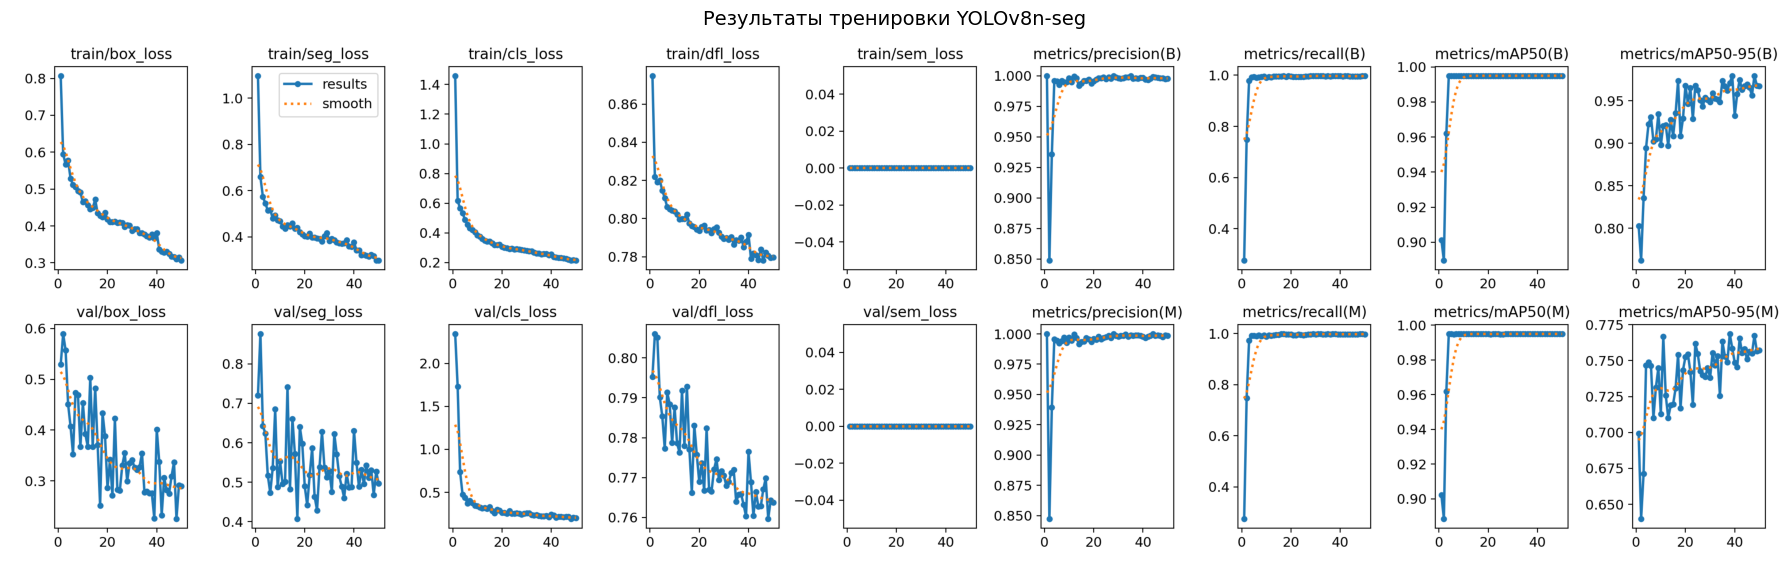

In [16]:
# Графики тренировки
from PIL import Image

results_dir = 'runs/segment/yolo_seg_train'
results_img_path = f"{results_dir}/results.png"
if os.path.exists(results_img_path):
    img = Image.open(results_img_path)
    fig, ax = plt.subplots(figsize=(18, 12))
    ax.imshow(img)
    ax.axis('off')
    ax.set_title("Результаты тренировки YOLOv8n-seg", fontsize=14)
    plt.tight_layout()
    plt.show()
else:
    print(f"Файл {results_img_path} не найден.")

In [17]:
# Загрузка лучшей модели
best_model_path = f"{results_dir}/weights/best.pt"
best_model = YOLO(best_model_path)
print(f"Модель загружена: {best_model_path}")

Модель загружена: runs/segment/yolo_seg_train/weights/best.pt


In [ ]:
# Стандартная валидация YOLO
val_results = best_model.val(
    data=yaml_path,
    imgsz=640,
    batch=8,         
    workers=0, 
    conf=0.25,
    iou=0.5,
    split='val',
    save=True,
    save_txt=True,
    name='yolo_seg_val',
    exist_ok=True,
    verbose=True
)

print(f"\nmAP50 (box):   {val_results.box.map50:.4f}")
print(f"mAP50-95 (box):  {val_results.box.map:.4f}")
if hasattr(val_results, 'segs') and val_results.segs is not None:
    print(f"mAP50 (mask):  {val_results.segs.map50:.4f}")
    print(f"mAP50-95 (mask): {val_results.segs.map:.4f}")


Ultralytics 8.4.56  Python-3.14.3 torch-2.11.0+cu128 CUDA:0 (NVIDIA GeForce RTX 5070 Laptop GPU, 8151MiB)
val: Fast image access  (ping: 0.00.0 ms, read: 633.9327.1 MB/s, size: 45.6 KB)
val: Scanning C:\Users\Daniil\Desktop\Recent Study\2 семестр\Двумерная графика и обработка видео\Practice_6\yolo_seg_dataset\labels\val.cache... 100 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 100/100 46.6Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Mask(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 13/13 3.4it/s 3.8s0.3s
                   all        100        937      0.999      0.996      0.995      0.979          1      0.999      0.995      0.812
Speed: 0.4ms preprocess, 3.6ms inference, 0.0ms loss, 1.6ms postprocess per image
Results saved to C:\Users\Daniil\Desktop\Recent Study\2 \    \Practice_6\runs\segment\yolo_seg_val

mAP50 (box):   0.9950
mAP50-95 (box):  0.9794


In [ ]:
# Тюнинг confidence + морфология + watershed
gt_dir = f"{SEG_DATASET_DIR}/labels/val"
val_img_dir = f"{SEG_DATASET_DIR}/images/val"

# GT
image_names = sorted([f.replace('.txt', '') for f in os.listdir(gt_dir) if f.endswith('.txt')])
gt_counts = {}
for name in image_names:
    with open(os.path.join(gt_dir, f"{name}.txt")) as f:
        gt_counts[name] = len([l for l in f.readlines() if l.strip()])

# Инференс на каждом изображении
print(f"Инференс YOLOv8n-seg на {len(image_names)} val изобр. (conf=0.01)...")
all_seg_detections = {}  # name -> [(conf, mask_array), ...]

for name in tqdm(image_names):
    img_path = os.path.join(val_img_dir, f"{name}.jpg")
    results = best_model(img_path, conf=0.01, verbose=False)

    dets = []
    if results and len(results) > 0 and results[0].masks is not None:
        for j, mask in enumerate(results[0].masks):
            conf = results[0].boxes[j].conf[0].item()
            mask_array = mask.data.cpu().numpy().squeeze()  # (H, W) bool
            dets.append((conf, mask_array))

    all_seg_detections[name] = dets


# Метод 1: Подсчёт по YOLO-инстансам (фильтр по conf)
print(f"\n{'='*70}")
print(f"{'Метод 1: YOLO instances (фильтр по confidence)'}")
print(f"{'Conf':>6} | {'<10%':>6} | {'MAE':>6} | {'Mean RE':>8} | {'Вердикт':>10}")
print("-" * 70)

best_conf = 0.25
best_pct = 0

for conf_thresh in np.arange(0.05, 0.60, 0.05):
    correct = 0
    total = len(image_names)
    abs_errors = []
    rel_errors_valid = []

    for name in image_names:
        gt = gt_counts[name]
        pred_count = sum(1 for (conf, _) in all_seg_detections.get(name, [])
                         if conf >= conf_thresh)

        abs_err = abs(pred_count - gt)
        abs_errors.append(abs_err)

        if gt > 0:
            rel_err = abs_err / gt
            rel_errors_valid.append(rel_err)
            if rel_err < 0.10:
                correct += 1
        elif pred_count == 0:
            correct += 1

    pct = correct / total * 100
    mae = np.mean(abs_errors)
    mean_re = np.mean(rel_errors_valid) if rel_errors_valid else 0
    verdict = "***" if pct >= 90 else ""
    print(f"{conf_thresh:6.2f} | {pct:5.1f}% | {mae:6.2f} | {mean_re:8.4f} | {verdict:>10}")

    if pct > best_pct:
        best_pct = pct
        best_conf = conf_thresh

print("-" * 70)
print(f"ЛУЧШИЙ conf (instances) = {best_conf:.2f} → {best_pct:.1f}%")


# Метод 2: Морфологический подсчёт на объединённой маске
print(f"\n{'='*70}")
print(f"{'Метод 2: Морфология на объединённой маске'}")
print(f"{'Kernel':>6} | {'MinArea':>7} | {'<10%':>6} | {'MAE':>6} | {'Mean RE':>8} | {'Вердикт':>10}")
print("-" * 70)

best_kernel = 5
best_min_area = 50
best_morph_pct = 0

# Фиксируем conf для сборки маски
CONF_FOR_MORPH = 0.15  # низкий conf, чтобы не терять маски

for ksize in [3, 5, 7, 9]:
    for min_area in [30, 50, 80, 120]:
        correct = 0
        total = len(image_names)
        abs_errors = []
        rel_errors_valid = []

        for name in image_names:
            gt = gt_counts[name]
            dets = all_seg_detections.get(name, [])

            # Объединяем маски с conf >= CONF_FOR_MORPH
            if dets:
                h, w = dets[0][1].shape
                combined = np.zeros((h, w), dtype=np.uint8)
                for (conf, mask_arr) in dets:
                    if conf >= CONF_FOR_MORPH:
                        combined[mask_arr > 0.5] = 255

                morph_count, _ = count_cells_by_morphology(combined, ksize, min_area)
            else:
                morph_count = 0

            abs_err = abs(morph_count - gt)
            abs_errors.append(abs_err)

            if gt > 0:
                rel_err = abs_err / gt
                rel_errors_valid.append(rel_err)
                if rel_err < 0.10:
                    correct += 1
            elif morph_count == 0:
                correct += 1

        pct = correct / total * 100
        mae = np.mean(abs_errors)
        mean_re = np.mean(rel_errors_valid) if rel_errors_valid else 0
        verdict = "***" if pct >= 90 else ""
        print(f"{ksize:6d} | {min_area:7d} | {pct:5.1f}% | {mae:6.2f} | {mean_re:8.4f} | {verdict:>10}")

        if pct > best_morph_pct:
            best_morph_pct = pct
            best_kernel = ksize
            best_min_area = min_area

print("-" * 70)
print(f"ЛУЧШИЙ морфология: kernel={best_kernel}, min_area={best_min_area} -> {best_morph_pct:.1f}%")
print(f"{'='*70}")

# ── Метод 3: Watershed + Distance Transform на объединённой маске ──
print(f"\n{'='*70}")
print(f"{'Метод 3: Watershed + Distance Transform'}")
print(f"{'DistT':>5} | {'MinArea':>7} | {'<10%':>6} | {'MAE':>6} | {'Mean RE':>8} | {'Вердикт':>10}")
print("-" * 70)

best_dist_thresh = 0.4
best_ws_min_area = 50
best_ws_pct = 0

CONF_FOR_WS = CONF_FOR_MORPH

for dist_ratio in [0.3, 0.4, 0.5, 0.6, 0.7]:
    for min_area in [30, 50, 80, 120]:
        correct = 0
        total = len(image_names)
        abs_errors = []
        rel_errors_valid = []

        for name in image_names:
            gt = gt_counts[name]
            dets = all_seg_detections.get(name, [])

            if dets:
                h, w = dets[0][1].shape
                combined = np.zeros((h, w), dtype=np.uint8)
                for (conf, mask_arr) in dets:
                    if conf >= CONF_FOR_WS:
                        combined[mask_arr > 0.5] = 255

                ws_count, _ = count_cells_by_watershed(combined, dist_ratio, min_area)
            else:
                ws_count = 0

            abs_err = abs(ws_count - gt)
            abs_errors.append(abs_err)

            if gt > 0:
                rel_err = abs_err / gt
                rel_errors_valid.append(rel_err)
                if rel_err < 0.10:
                    correct += 1
            elif ws_count == 0:
                correct += 1

        pct = correct / total * 100
        mae = np.mean(abs_errors)
        mean_re = np.mean(rel_errors_valid) if rel_errors_valid else 0
        verdict = "***" if pct >= 90 else ""
        print(f"{dist_ratio:5.2f} | {min_area:7d} | {pct:5.1f}% | {mae:6.2f} | {mean_re:8.4f} | {verdict:>10}")

        if pct > best_ws_pct:
            best_ws_pct = pct
            best_dist_thresh = dist_ratio
            best_ws_min_area = min_area

print("-" * 70)
print(f"ЛУЧШИЙ watershed: dist_ratio={best_dist_thresh:.2f}, min_area={best_ws_min_area} -> {best_ws_pct:.1f}%")
print(f"{'='*70}")

Инференс YOLOv8n-seg на 100 val изобр. (conf=0.01)...


100%|██████████| 100/100 [00:01<00:00, 85.17it/s]



Метод 1: YOLO instances (фильтр по confidence)
  Conf |   <10% |    MAE |  Mean RE |    Вердикт
----------------------------------------------------------------------
  0.05 |  97.0% |   0.14 |   0.0115 |        ***
  0.10 |  98.0% |   0.08 |   0.0068 |        ***
  0.15 |  98.0% |   0.07 |   0.0061 |        ***
  0.20 |  98.0% |   0.07 |   0.0061 |        ***
  0.25 |  98.0% |   0.08 |   0.0068 |        ***
  0.30 |  98.0% |   0.08 |   0.0068 |        ***
  0.35 |  98.0% |   0.07 |   0.0061 |        ***
  0.40 |  98.0% |   0.07 |   0.0061 |        ***
  0.45 |  99.0% |   0.05 |   0.0041 |        ***
  0.50 |  99.0% |   0.03 |   0.0025 |        ***
  0.55 |  99.0% |   0.03 |   0.0025 |        ***
----------------------------------------------------------------------
ЛУЧШИЙ conf (instances) = 0.45 → 99.0%

Метод 2: Морфология на объединённой маске
Kernel | MinArea |   <10% |    MAE |  Mean RE |    Вердикт
----------------------------------------------------------------------
     3 |  

In [ ]:
# Итоговый подсчёт (лучший из трёх методов)
METHOD = 'instances'
best_method_pct = best_pct

if best_morph_pct > best_method_pct:
    METHOD = 'morphology'
    best_method_pct = best_morph_pct

if best_ws_pct > best_method_pct:
    METHOD = 'watershed'
    best_method_pct = best_ws_pct

OPTIMAL_CONF = best_conf if METHOD == 'instances' else CONF_FOR_MORPH

print(f"{'='*70}")
print(f"СВОДКА МЕТОДОВ (val)")
print(f"{'='*70}")
print(f"  1. YOLO instances:   {best_pct:.1f}% (conf={best_conf:.2f})")
print(f"  2. Морфология:       {best_morph_pct:.1f}% (kernel={best_kernel}, min_area={best_min_area})")
print(f"  3. Watershed:        {best_ws_pct:.1f}% (dist={best_dist_thresh:.2f}, min_area={best_ws_min_area})")
print(f"{'='*70}")
print(f"ЛУЧШИЙ МЕТОД: {METHOD} ({best_method_pct:.1f}%)")
print(f"{'='*70}")

gt_arr = []
pred_arr = []
error_details = []

for name in image_names:
    gt = gt_counts[name]
    dets = all_seg_detections.get(name, [])

    if METHOD == 'instances':
        pred_count = sum(1 for (conf, _) in dets if conf >= OPTIMAL_CONF)

    elif METHOD == 'morphology':
        if dets:
            h, w = dets[0][1].shape
            combined = np.zeros((h, w), dtype=np.uint8)
            for (conf, mask_arr) in dets:
                if conf >= CONF_FOR_MORPH:
                    combined[mask_arr > 0.5] = 255
            pred_count, _ = count_cells_by_morphology(combined, best_kernel, best_min_area)
        else:
            pred_count = 0

    elif METHOD == 'watershed':
        if dets:
            h, w = dets[0][1].shape
            combined = np.zeros((h, w), dtype=np.uint8)
            for (conf, mask_arr) in dets:
                if conf >= CONF_FOR_WS:
                    combined[mask_arr > 0.5] = 255
            pred_count, _ = count_cells_by_watershed(combined, best_dist_thresh, best_ws_min_area)
        else:
            pred_count = 0

    gt_arr.append(gt)
    pred_arr.append(pred_count)

    if gt > 0:
        rel_err = abs(pred_count - gt) / gt
    else:
        rel_err = 0.0 if pred_count == 0 else float('inf')

    ok = rel_err < 0.10
    error_details.append({'name': name, 'gt': gt, 'pred': pred_count,
                          'rel_err': rel_err, 'ok': ok})

gt_arr = np.array(gt_arr)
pred_arr = np.array(pred_arr)

print(f"\n{'='*65}")
print(f"РЕЗУЛЬТАТЫ ПОДСЧЁТА ({METHOD}, val)")
print(f"{'='*65}")
print(f"Изображений: {len(gt_arr)}")
correct = sum(1 for e in error_details if e['ok'])
print(f"Корректных (< 10%): {correct}/{len(gt_arr)} ({correct/len(gt_arr)*100:.1f}%)")
print(f"Средний GT:  {gt_arr.mean():.1f}")
print(f"Средний Pred: {pred_arr.mean():.1f}")
print(f"MAE: {np.mean(np.abs(pred_arr - gt_arr)):.2f}")

valid_re = [e['rel_err'] for e in error_details if e['rel_err'] != float('inf')]
print(f"Ср. относ. ошибка: {np.mean(valid_re):.4f}")

print(f"\nПо количеству клеток:")
for c in sorted(set(gt_arr)):
    mask = gt_arr == c
    n = mask.sum()
    preds_c = pred_arr[mask]
    print(f"  GT={c:2d}: {n:3d} изобр., MAE={np.mean(np.abs(preds_c - c)):.2f}")

if correct / len(gt_arr) >= 0.9:
    print(f"\n✓ ЦЕЛЬ ДОСТИГНУТА: {correct/len(gt_arr)*100:.1f}% >= 90%")
else:
    print(f"\n✗ Цель НЕ достигнута: {correct/len(gt_arr)*100:.1f}% < 90%")

СВОДКА МЕТОДОВ (val)
  1. YOLO instances:   99.0% (conf=0.45)
  2. Морфология:       54.0% (kernel=7, min_area=30)
  3. Watershed:        75.0% (dist=0.30, min_area=30)
ЛУЧШИЙ МЕТОД: instances (99.0%)

РЕЗУЛЬТАТЫ ПОДСЧЁТА (instances, val)
Изображений: 100
Корректных (< 10%): 99/100 (99.0%)
Средний GT:  9.4
Средний Pred: 9.4
MAE: 0.05
Ср. относ. ошибка: 0.0041

По количеству клеток:
  GT= 5:  14 изобр., MAE=0.00
  GT= 6:  15 изобр., MAE=0.00
  GT= 7:  11 изобр., MAE=0.00
  GT= 8:   8 изобр., MAE=0.00
  GT= 9:   9 изобр., MAE=0.11
  GT=10:   5 изобр., MAE=0.00
  GT=11:   4 изобр., MAE=0.00
  GT=12:   7 изобр., MAE=0.00
  GT=13:   9 изобр., MAE=0.22
  GT=14:  10 изобр., MAE=0.20
  GT=15:   8 изобр., MAE=0.00

✓ ЦЕЛЬ ДОСТИГНУТА: 99.0% >= 90%


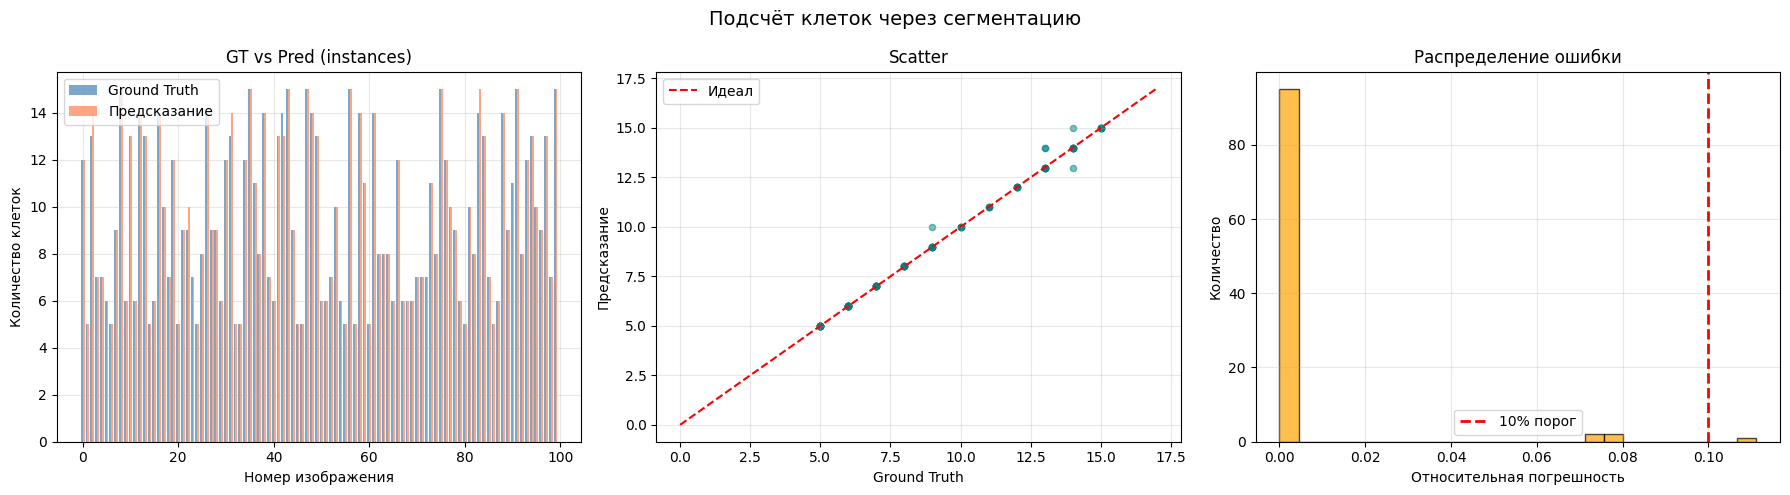

In [22]:
# Визуализация результатов
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].bar(np.arange(len(gt_arr)) - 0.2, gt_arr, 0.4, label='Ground Truth',
            color='steelblue', alpha=0.7)
axes[0].bar(np.arange(len(pred_arr)) + 0.2, pred_arr, 0.4, label='Предсказание',
            color='coral', alpha=0.7)
axes[0].set_xlabel("Номер изображения")
axes[0].set_ylabel("Количество клеток")
axes[0].set_title(f"GT vs Pred ({METHOD})")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].scatter(gt_arr, pred_arr, alpha=0.5, s=20, c='teal')
max_val = max(gt_arr.max(), pred_arr.max()) + 2
axes[1].plot([0, max_val], [0, max_val], 'r--', label='Идеал')
axes[1].set_xlabel("Ground Truth")
axes[1].set_ylabel("Предсказание")
axes[1].set_title("Scatter")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

rel_errors = [e['rel_err'] for e in error_details if e['rel_err'] != float('inf')]
axes[2].hist(rel_errors, bins=25, color='orange', edgecolor='black', alpha=0.7)
axes[2].axvline(x=0.1, color='red', linestyle='--', linewidth=2, label='10% порог')
axes[2].set_xlabel("Относительная погрешность")
axes[2].set_ylabel("Количество")
axes[2].set_title("Распределение ошибки")
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.suptitle("Подсчёт клеток через сегментацию", fontsize=14)
plt.tight_layout()
plt.show()

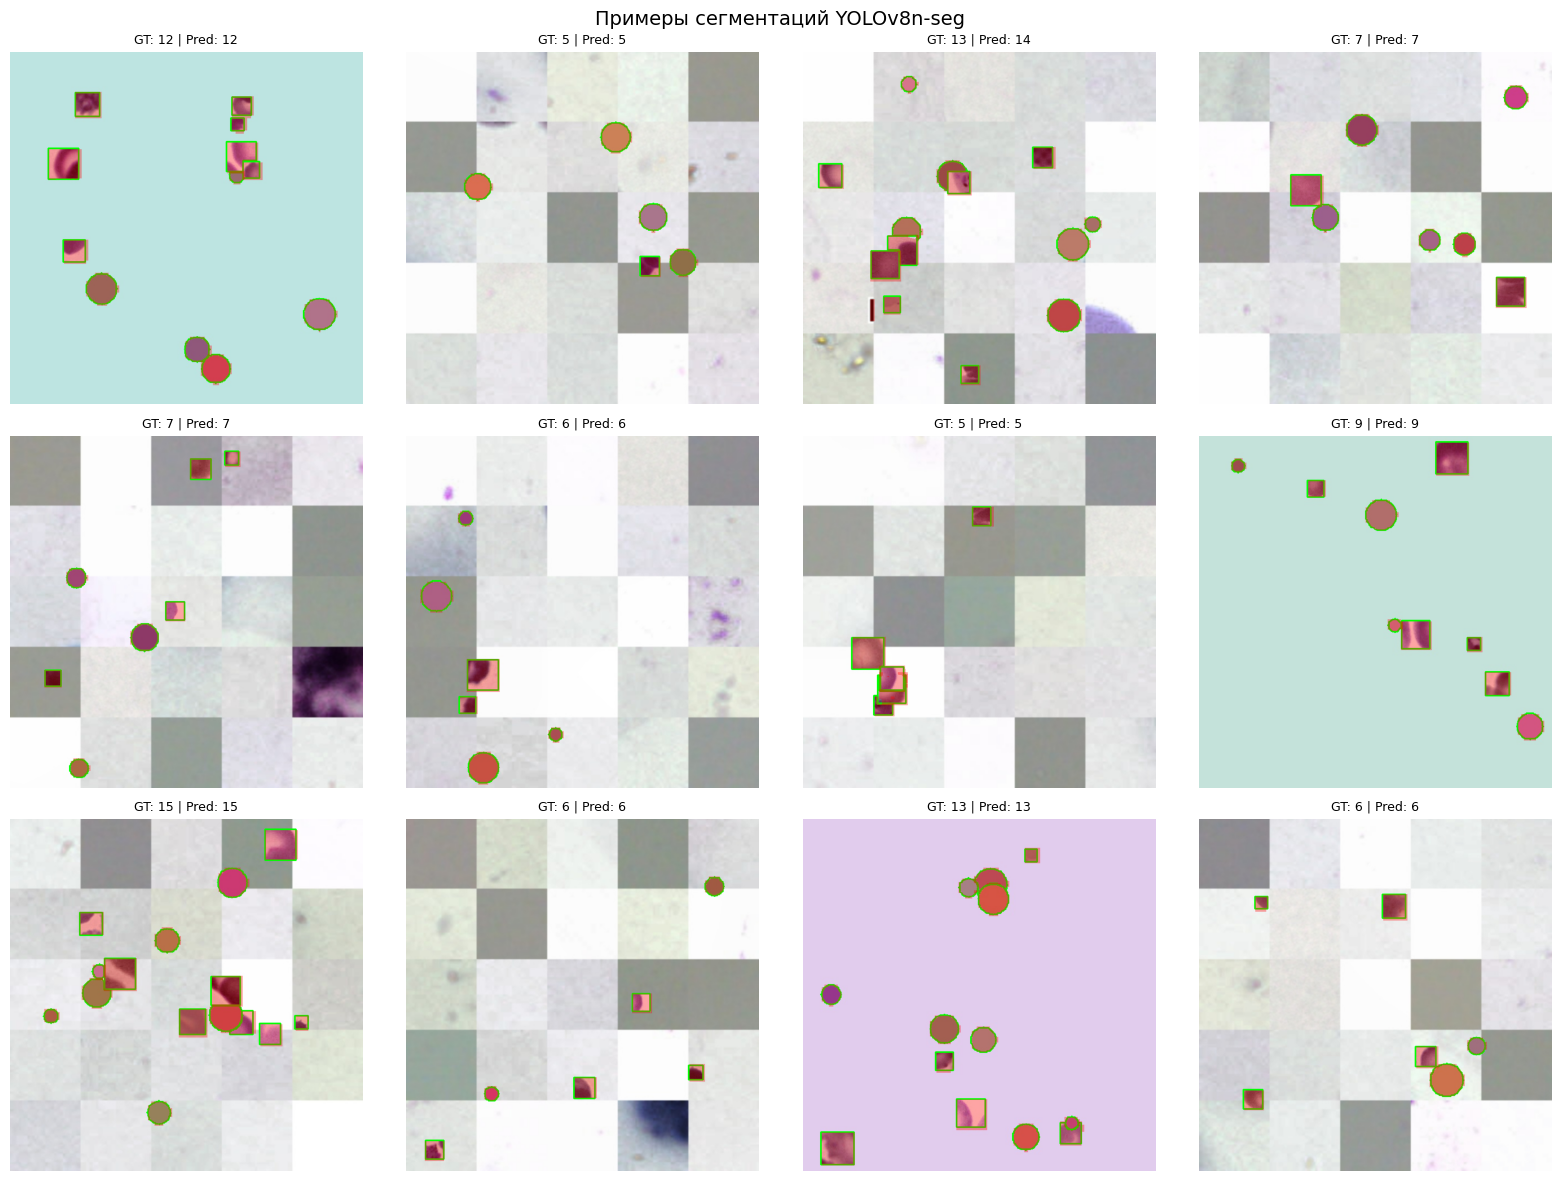

Зелёные контуры — GT полигоны, красная заливка — YOLO маски


In [23]:
# Визуализация сегментаций на примерах
val_img_dir = f"{SEG_DATASET_DIR}/images/val"
sample_imgs = sorted(os.listdir(val_img_dir))[:12]

fig, axes = plt.subplots(3, 4, figsize=(16, 12))
fig.suptitle("Примеры сегментаций YOLOv8n-seg", fontsize=14)

for i, img_name in enumerate(sample_imgs):
    img_path = os.path.join(val_img_dir, img_name)
    img = cv2.imread(img_path)

    base = img_name.replace('.jpg', '')

    # GT polygons
    gt_path = os.path.join(gt_dir, f"{base}.txt")
    gt_polys = []
    with open(gt_path) as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) >= 7:
                vals = [float(v) for v in parts[1:]]
                gt_polys.append(vals)

    # YOLO сегментация
    pred = best_model(img_path, conf=OPTIMAL_CONF, verbose=False)

    # Отрисовка GT
    h, w = img.shape[:2]
    for poly in gt_polys:
        pts = np.array(poly).reshape(-1, 2)
        pts[:, 0] *= w; pts[:, 1] *= h
        cv2.polylines(img, [pts.astype(np.int32)], True, (0, 255, 0), 2)

    # Отрисовка предсказанных масок
    if pred and len(pred) > 0 and pred[0].masks is not None:
        for j, mask in enumerate(pred[0].masks):
            m = mask.data.cpu().numpy().squeeze()
            overlay = img.copy()
            overlay[m > 0.5] = (0, 0, 255)
            img = cv2.addWeighted(overlay, 0.35, img, 0.65, 0)

    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    row, col = i // 4, i % 4
    axes[row, col].imshow(img_rgb)

    gt_n = len(gt_polys)
    pred_n = len(pred[0].masks) if pred and pred[0].masks else 0
    axes[row, col].set_title(f"GT: {gt_n} | Pred: {pred_n}", fontsize=9)
    axes[row, col].axis('off')

plt.tight_layout()
plt.show()
print("Зелёные контуры — GT полигоны, красная заливка — YOLO маски")

## Часть 7: Итоговый тест на новых данных

In [ ]:
# Итоговый тест (100 новых изображений)
test_dir = "yolo_seg_test"
if os.path.exists(test_dir):
    shutil.rmtree(test_dir)
os.makedirs(f"{test_dir}/images", exist_ok=True)
os.makedirs(f"{test_dir}/labels", exist_ok=True)

test_dataset = BloodCellDataset(
    img_size=IMG_SIZE, dataset_size=TEST_SIZE,
    bg_patches=bg_patches_list, cell_patches=cell_patches_list,
    min_cells=MIN_CELLS, max_cells=MAX_CELLS,
    min_cell_radius=MIN_CELL_RADIUS, max_cell_radius=MAX_CELL_RADIUS,
    seed=SEED + 999
)

test_results = []

for i in tqdm(range(len(test_dataset)), desc="Тест"):
    clean_img, polygons, cell_mask, gt_count = test_dataset[i]

    img_name = f"test_{i:05d}.jpg"
    cv2.imwrite(f"{test_dir}/images/{img_name}", clean_img)

    with open(f"{test_dir}/labels/{img_name.replace('.jpg', '.txt')}", 'w') as f:
        for poly in polygons:
            coords = ' '.join(f"{v:.6f}" for v in poly)
            f.write(f"{CLASS_ID} {coords}\n")

    # Сегментация
    pred = best_model(f"{test_dir}/images/{img_name}", conf=0.01, verbose=False)

    dets = []
    if pred and len(pred) > 0 and pred[0].masks is not None:
        for j, mask in enumerate(pred[0].masks):
            conf = pred[0].boxes[j].conf[0].item()
            m = mask.data.cpu().numpy().squeeze()
            dets.append((conf, m))

    if METHOD == 'instances':
        pred_count = sum(1 for (c, _) in dets if c >= OPTIMAL_CONF)
    elif METHOD == 'morphology':
        if dets:
            h, w = dets[0][1].shape
            combined = np.zeros((h, w), dtype=np.uint8)
            for (conf, m) in dets:
                if conf >= CONF_FOR_MORPH:
                    combined[m > 0.5] = 255
            pred_count, _ = count_cells_by_morphology(combined, OPTIMAL_KERNEL, OPTIMAL_MIN_AREA)
        else:
            pred_count = 0
    elif METHOD == 'watershed':
        if dets:
            h, w = dets[0][1].shape
            combined = np.zeros((h, w), dtype=np.uint8)
            for (conf, m) in dets:
                if conf >= CONF_FOR_WS:
                    combined[m > 0.5] = 255
            pred_count, _ = count_cells_by_watershed(combined, best_dist_thresh, best_ws_min_area)
        else:
            pred_count = 0

    if gt_count > 0:
        rel_err = abs(pred_count - gt_count) / gt_count
    else:
        rel_err = 0.0 if pred_count == 0 else float('inf')

    test_results.append({
        'img': img_name, 'gt': gt_count, 'pred': pred_count,
        'rel_err': rel_err, 'ok': rel_err < 0.10
    })

# Анализ
total_t = len(test_results)
correct_t = sum(1 for r in test_results if r['ok'])
gt_t = np.array([r['gt'] for r in test_results])
pred_t = np.array([r['pred'] for r in test_results])
valid_err = [r['rel_err'] for r in test_results if r['rel_err'] != float('inf')]

print(f"\n{'='*65}")
print(f"ИТОГОВЫЙ ТЕСТ ({total_t} изобр., seed={SEED + 999}, метод={METHOD})")
print(f"{'='*65}")
print(f"Корректных: {correct_t}/{total_t} ({correct_t/total_t*100:.1f}%)")
print(f"MAE: {np.mean(np.abs(pred_t - gt_t)):.2f}")
print(f"Ср. относ. ошибка: {np.mean(valid_err):.4f}")

for c in sorted(set(gt_t)):
    mask = gt_t == c
    print(f"  GT={c:2d}: {mask.sum():3d} изобр., MAE={np.mean(np.abs(pred_t[mask] - c)):.2f}")

if correct_t / total_t >= 0.9:
    print(f"\n✓ ЦЕЛЬ ДОСТИГНУТА: {correct_t/total_t*100:.1f}% ≥ 90%")
else:
    print(f"\n✗ Цель НЕ достигнута: {correct_t/total_t*100:.1f}% < 90%")

Тест: 100%|██████████| 50/50 [00:02<00:00, 20.85it/s]


ИТОГОВЫЙ ТЕСТ (50 изобр., seed=1041, метод=instances)
Корректных: 49/50 (98.0%)
MAE: 0.02
Ср. относ. ошибка: 0.0022
  GT= 5:   2 изобр., MAE=0.00
  GT= 6:   4 изобр., MAE=0.00
  GT= 7:   5 изобр., MAE=0.00
  GT= 8:   4 изобр., MAE=0.00
  GT= 9:   7 изобр., MAE=0.14
  GT=10:   5 изобр., MAE=0.00
  GT=11:   3 изобр., MAE=0.00
  GT=12:   7 изобр., MAE=0.00
  GT=13:   7 изобр., MAE=0.00
  GT=14:   3 изобр., MAE=0.00
  GT=15:   3 изобр., MAE=0.00

✓ ЦЕЛЬ ДОСТИГНУТА: 98.0% ≥ 90%


In [28]:
# Сохранение модели
save_path = "yolo_seg_model.pt"
best_model.save(save_path)
print(f"Модель сохранена: {save_path}")

Модель сохранена: yolo_seg_model.pt
